# Baseline Model: Linear Regression

This notebook implements the project baseline model for **national electricity demand forecasting** using:
- lagged demand features (autoregressive signal)
- socio-economic features (`gdp`, `population`, `gdp_per_capita`)

**Target:** `electricity_demand` (TWh)  
**Train/Test split:** Train = 2003-2019, Test = 2020-2023  
**Metrics:** RMSE and MAE

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
# Load dataset
DATA_PATH = 'data/model_dataset.csv'
df = pd.read_csv(DATA_PATH)

print(f'Loaded: {DATA_PATH}')
print(f'Shape: {df.shape[0]} rows x {df.shape[1]} columns')
print(f'Countries: {df.country.nunique()}')
print(f'Year range: {df.year.min()}-{df.year.max()}')
df.head()

Loaded: data/model_dataset.csv
Shape: 667 rows x 18 columns
Countries: 28
Year range: 2000-2023


,country,year,population,gdp,electricity_demand,electricity_generation,fossil_electricity,renewables_electricity,nuclear_electricity,coal_electricity,gas_electricity,oil_electricity,solar_electricity,wind_electricity,hydro_electricity,primary_energy_consumption,greenhouse_gas_emissions,carbon_intensity_elec
0,Argentina,2000,37213986.0,5.364810e+11,90.199997,88.980003,53.799999,29.000000,6.18,1.78,48.880001,3.14,0.0,0.03,28.580000,703.634705,31.629999,355.470001
1,Argentina,2001,37624817.0,5.148673e+11,91.889999,90.139999,46.090000,36.990002,7.06,1.36,43.259998,1.47,0.0,0.05,36.580002,687.340759,27.230000,302.089996
2,Argentina,2002,38029345.0,4.605585e+11,90.510002,84.589996,42.389999,36.380001,5.82,0.81,40.709999,0.87,0.0,0.07,35.779999,658.151062,24.940001,294.829987
3,Argentina,2003,38424283.0,5.031042e+11,97.099998,92.070000,49.740002,34.759998,7.57,0.94,47.750000,1.05,0.0,0.08,33.799999,704.757751,29.129999,316.390015
4,Argentina,2004,38815915.0,5.503063e+11,103.730003,100.260002,60.990002,31.400000,7.87,1.68,55.209999,4.10,0.0,0.07,30.459999,751.156982,35.860001,357.670013


In [3]:
# Feature engineering
TARGET = 'electricity_demand'
LAGS = [1, 2, 3]

df = df.sort_values(['country', 'year']).reset_index(drop=True)

for lag in LAGS:
    df[f'demand_lag{lag}'] = df.groupby('country')[TARGET].shift(lag)

# Lagged year-over-year change (no leakage): (t-1) - (t-2)
df['demand_yoy_change'] = df.groupby('country')[TARGET].diff().shift(1)

# Exogenous interaction
df['gdp_per_capita'] = df['gdp'] / df['population']

FEATURE_COLS = [
    'demand_lag1', 'demand_lag2', 'demand_lag3',
    'demand_yoy_change', 'gdp', 'population', 'gdp_per_capita'
]

df_model = df.dropna(subset=FEATURE_COLS + [TARGET]).copy()
print(f'Usable rows after lag features: {len(df_model)}')
df_model[['country', 'year'] + FEATURE_COLS + [TARGET]].head()

Usable rows after lag features: 583


,country,year,demand_lag1,demand_lag2,demand_lag3,demand_yoy_change,gdp,population,gdp_per_capita,electricity_demand
3,Argentina,2003,90.510002,91.889999,90.199997,-1.379997,5.031042e+11,38424283.0,13093.390906,97.099998
4,Argentina,2004,97.099998,90.510002,91.889999,6.589996,5.503063e+11,38815915.0,14177.337496,103.730003
5,Argentina,2005,103.730003,97.099998,90.510002,6.630005,6.010504e+11,39216786.0,15326.355866,109.629997
6,Argentina,2006,109.629997,103.730003,97.099998,5.899994,6.522968e+11,39622113.0,16462.948715,115.790001
7,Argentina,2007,115.790001,109.629997,103.730003,6.160004,7.147252e+11,40016767.0,17860.643216,121.120003


In [4]:
# Temporal train/test split
TRAIN_END = 2019
TEST_START = 2020

train = df_model[df_model['year'] <= TRAIN_END].copy()
test = df_model[df_model['year'] >= TEST_START].copy()

X_train, y_train = train[FEATURE_COLS], train[TARGET]
X_test, y_test = test[FEATURE_COLS], test[TARGET]

print(f'Train rows: {len(train)}')
print(f'Test rows: {len(test)}')
print(f'Features: {FEATURE_COLS}')

Train rows: 471
Test rows: 112
Features: ['demand_lag1', 'demand_lag2', 'demand_lag3', 'demand_yoy_change', 'gdp', 'population', 'gdp_per_capita']


In [5]:
# Train baseline model
model = LinearRegression()
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

In [6]:
# Evaluation metrics
def eval_metrics(y_true, y_pred):
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    return rmse, mae

train_rmse, train_mae = eval_metrics(y_train, y_pred_train)
test_rmse, test_mae = eval_metrics(y_test, y_pred_test)

print('Overall Metrics')
print(f'Train RMSE: {train_rmse:.3f} TWh | Train MAE: {train_mae:.3f} TWh')
print(f'Test RMSE : {test_rmse:.3f} TWh | Test MAE : {test_mae:.3f} TWh')

Overall Metrics
Train RMSE: 37.381 TWh | Train MAE: 15.303 TWh
Test RMSE : 58.749 TWh | Test MAE : 23.007 TWh


In [7]:
# Per-country test metrics
country_rows = []
for country in sorted(test['country'].unique()):
    mask = test['country'] == country
    yt = y_test[mask]
    yp = y_pred_test[mask.values]
    rmse = np.sqrt(mean_squared_error(yt, yp))
    mae = mean_absolute_error(yt, yp)
    country_rows.append({
        'country': country,
        'n_test': int(mask.sum()),
        'RMSE': round(float(rmse), 3),
        'MAE': round(float(mae), 3),
    })

country_metrics = pd.DataFrame(country_rows).sort_values('RMSE', ascending=False)
country_metrics

,country,n_test,RMSE,MAE
4,China,4,263.758,232.654
27,United States,4,125.689,124.125
10,India,4,77.178,55.581
12,Japan,4,30.914,26.876
25,Ukraine,4,27.313,17.660
8,France,4,24.780,21.104
9,Germany,4,20.378,12.099
11,Indonesia,4,19.999,17.985
23,South Korea,4,19.451,16.290
2,Brazil,4,17.854,16.705


In [8]:
# Coefficients (interpretability)
coef_df = pd.DataFrame({
    'feature': FEATURE_COLS,
    'coefficient': model.coef_
}).sort_values('coefficient', key=np.abs, ascending=False)

print(f'Intercept: {model.intercept_:.4f}')
coef_df

Intercept: 1.0276


,feature,coefficient
0,demand_lag1,8.564467e-01
3,demand_yoy_change,5.524840e-01
1,demand_lag2,3.039635e-01
2,demand_lag3,-1.045299e-01
6,gdp_per_capita,-1.054594e-04
5,population,8.096609e-08
4,gdp,-1.375722e-11


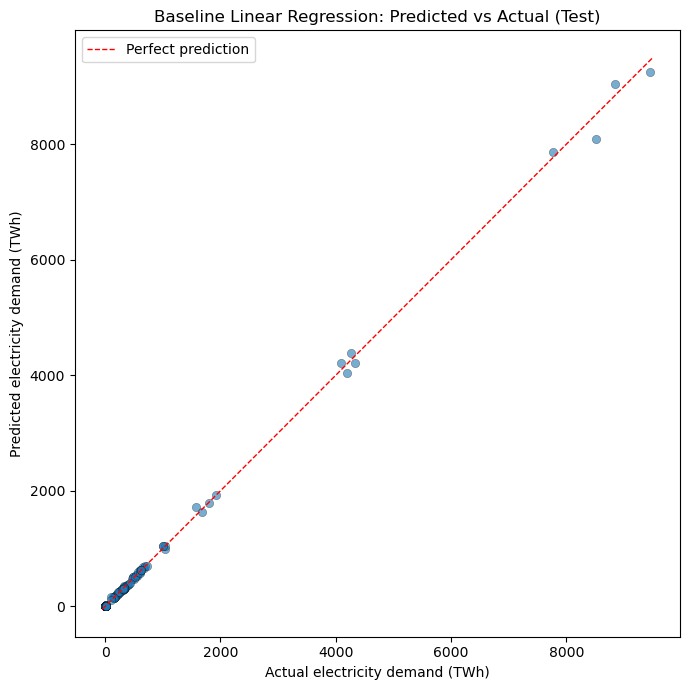

In [9]:
# Plot 1: Predicted vs Actual (Test)
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_test, alpha=0.6, edgecolors='k', linewidths=0.3)
lims = [min(y_test.min(), y_pred_test.min()) - 50, max(y_test.max(), y_pred_test.max()) + 50]
plt.plot(lims, lims, 'r--', linewidth=1, label='Perfect prediction')
plt.xlabel('Actual electricity demand (TWh)')
plt.ylabel('Predicted electricity demand (TWh)')
plt.title('Baseline Linear Regression: Predicted vs Actual (Test)')
plt.legend()
plt.tight_layout()
plt.show()

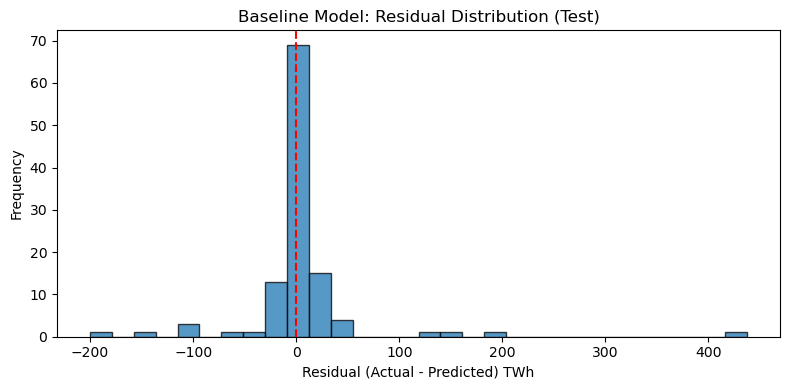

In [10]:
# Plot 2: Residual distribution
residuals = y_test.values - y_pred_test
plt.figure(figsize=(8, 4))
plt.hist(residuals, bins=30, edgecolor='k', alpha=0.75)
plt.axvline(0, color='r', linestyle='--')
plt.xlabel('Residual (Actual - Predicted) TWh')
plt.ylabel('Frequency')
plt.title('Baseline Model: Residual Distribution (Test)')
plt.tight_layout()
plt.show()

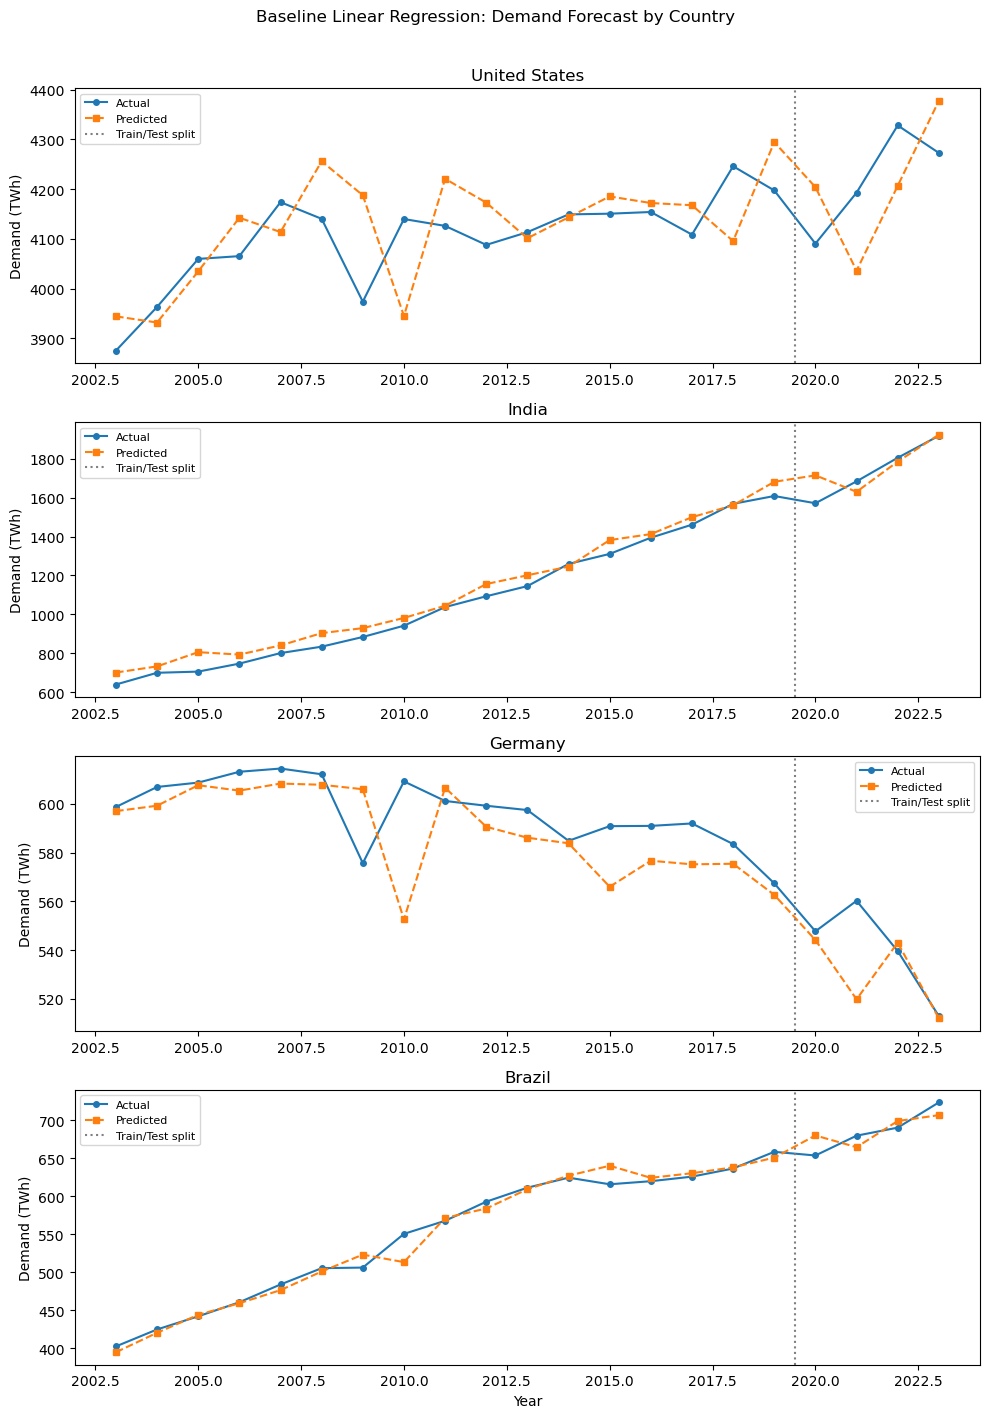

In [11]:
# Plot 3: Country-level overlays
sample_countries = ['United States', 'India', 'Germany', 'Brazil']
sample_countries = [c for c in sample_countries if c in df_model['country'].unique()]

fig, axes = plt.subplots(len(sample_countries), 1, figsize=(10, 3.5 * len(sample_countries)), sharex=False)
if len(sample_countries) == 1:
    axes = [axes]

for ax, country in zip(axes, sample_countries):
    cdf = df_model[df_model['country'] == country].copy()
    cdf['predicted'] = model.predict(cdf[FEATURE_COLS])

    ax.plot(cdf['year'], cdf[TARGET], 'o-', label='Actual', markersize=4)
    ax.plot(cdf['year'], cdf['predicted'], 's--', label='Predicted', markersize=4)
    ax.axvline(TEST_START - 0.5, color='gray', linestyle=':', label='Train/Test split')
    ax.set_title(country)
    ax.set_ylabel('Demand (TWh)')
    ax.legend(fontsize=8)

axes[-1].set_xlabel('Year')
fig.suptitle('Baseline Linear Regression: Demand Forecast by Country', y=1.01)
plt.tight_layout()
plt.show()

## Interpretation Notes

- This baseline is intentionally simple and interpretable.
- It should be compared directly against SARIMAX (same split and metrics).
- If SARIMAX cannot beat this baseline on Test RMSE/MAE, revisit feature engineering or SARIMAX specification.